# Kaggle Dataset EDA Investigation: Students Performance
**Dataset:** Students Performance

This notebook follows the required section for EDA activity. The analysis uses the uploaded `StudentsPerformance.csv` dataset and focused on describing data, distribution, outliers, group differences, relationships and limitation of intepretation.

## 1. Dataset Selection

### Dataset Information

| Requirements | Response |
|---|---|
| Dataset Name | Students Performance |
| Dataset URL | https://www.kaggle.com/datasets/spscientist/students-performance-in-exams/data |
| Dataset Author | JAKKI SESHAPANPU |
| Number of Rows | 1000 |
| Number of Features | 8 |
| Categorical Variables | gender, race/ethnicity, parental level of education, lunch, test preparation course |
| Dataset description | The dataset contains the exam scores and selected background characteristics of 1,000 students. The scores cover mathematics, reading, and writing, while the categorical variables describe gender, race/ethnicity, parental education, lunch type, and whether a test preparation course was completed. |
| Research/analysis question | **How do students' math, reading, and writing performance vary, and what relationships exist among their scores and selected student characteristics?** |

### Important variables
- **gender:** Gender of each student.
- **race/ethnicity:** student's race/ethnicity group, labeled A to E in the dataset.
- **parental level of education:** highest reported education level of a student's parent(s).
- **lunch:** lunch category, either standard or free/reduced.
- **test preparation course:** whether the student completed a preparation course or did not.
- **math score:** mathematics exam score from 0 to 100.
- **reading score:** reading exam score from 0 to 100.
- **writing score:** writing exam score from 0 to 100.

## 2. Data Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, pearsonr, spearmanr
from pathlib import Path
from IPython.display import display
import kagglehub
import shutil
import os

# # Download latest version
# path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
# project_path = os.getcwd()
# target_dir = os.path.join(project_path, "data")
#
# if os.path.exists(target_dir):
#     shutil.rmtree(target_dir)
# shutil.copytree(path, target_dir)
#
# print(f"Dataset successfully downloaded to {target_dir}")

df: pd.DataFrame = pd.read_csv('data/StudentsPerformance.csv')
print('Shape:', df.shape)
print(df.head())

Shape: (1000, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


/Users/stockland/Desktop/Projects/Students_Performance_in_Exams/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print('|----- head -----|')
display(df.head())

print('|----- tail -----|')
display(df.tail())

print('|----- info -----|')
display(df.info())

print('|----- descr -----|')
display(df.describe())

print('|----- missing values -----|')
display(df.isna().sum().to_frame('missing_values'))

print('|----- duplicate values -----|')
display(df.duplicated().sum())

print('|----- unique values -----|')
display(df.nunique().to_frame('unique_values'))

|----- head -----|


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


|----- tail -----|


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


|----- info -----|
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


...

,missing_values
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


|----- duplicate values -----|


np.int64(0)

|----- unique values -----|


,unique_values
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77


### Data Inspection Answers

- **Observations:** 1,000 students.
- **Variables:** 8 columns.
- **Numerical variables:** math score, reading score, and writing score.
- **Categorical variables:** gender, race/ethnicity, parental level of education, lunch, and test preparation course.
- **Missing values:** None of the 8 variables has missing values.
- **Duplicate observations:** 0 complete duplicate rows were found.
- **Largest/smallest ranges:** Math has the largest range (100 points), followed by writing (90) and reading (83). The variables use the same 0–100 score scale, so the different ranges are mainly caused by the observed minimum and maximum scores rather than different measurement units.
- **Preprocessing:** No missing-value treatment or duplicate removal is required. The categorical columns would need encoding if the data were later used for a machine-learning model. Column names contain spaces and a slash, so renaming them could also make coding easier, but it is not necessary for this descriptive EDA.

## 3. Summerize & Distribution

### A. Measure of Central Tendency

In [5]:
num_cols = ['math score', 'reading score', 'writing score']

central = pd.DataFrame({
    'mean': df[num_cols].mean(),
    'median': df[num_cols].median(),
    'mode': df[num_cols].mode().iloc[0],
})
central.index.name = 'Variables'
display(central)

,mean,median,mode
Variables,,,
math score,66.089,66.0,65
reading score,69.169,70.0,72
writing score,68.054,69.0,74


### Explanation

- **Math score:** The mean is **66.09**, meaning the average math score is about 66 points. The median is **66**, so the middle student also scored 66. The mode is **65**, the most frequently occurring score. Because the mean and median are almost identical, the distribution is close to symmetric, although the skewness value later shows a slight left skew. The median is useful as a typical value because it is not strongly affected by the few very low scores.
- **Reading score:** The mean is **69.17**, while the median is **70** and the mode is **72**. The mean is slightly lower than the median, which is consistent with a small amount of left skew. The median gives a useful description of a typical student because the lower scores pull the mean down slightly.
- **Writing score:** The mean is **68.05**, median **69**, and mode **74**. Again, the mean is below the median, suggesting slight left skew. The median is a good measure of the typical score because it represents the middle observation and is less affected by unusually low scores.

Overall, the three means are close to their medians, so none of the score distributions is extremely skewed.

### B. Variability

In [7]:
variability = pd.DataFrame({
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Range': df[num_cols].max() - df[num_cols].min(),
    'Variance': df[num_cols].var(),
    'Std. Dev.': df[num_cols].std()
})
variability.index.name = 'Variables'
display(variability.round(2))

,Min,Max,Range,Variance,Std. Dev.
Variables,,,,,
math score,0,100,100,229.92,15.16
reading score,17,100,83,213.17,14.60
writing score,10,100,90,230.91,15.20


### Explanation

- **Greatest variability:** Writing score has the largest standard deviation (**15.20**) and variance (**230.91**), very slightly higher than math.
- **Most consistent:** Reading score has the smallest standard deviation (**14.60**) and variance (**213.17**), so its scores are slightly more concentrated around its mean.
- **Meaning of standard deviation:** A standard deviation of about 15 points means individual scores commonly differ from the mean by roughly this amount, although not every observation will fall within exactly one standard deviation.
- **Is a large standard deviation necessarily a problem?** No. A large standard deviation can simply mean that students have widely different performance levels. It becomes a data-quality concern only when the spread is caused by errors, incorrect units, impossible values, or other data problems.

### C. Quantiles and Five-Number Summary

In [8]:
five_nums = pd.DataFrame({
    'Min': df[num_cols].min(),
    'Q1': df[num_cols].quantile(0.25),
    'Median': df[num_cols].median(),
    'Q3': df[num_cols].quantile(0.75),
    'Max': df[num_cols].max()
})

five_nums['IQR'] = five_nums['Q3'] - five_nums['Q1']
five_nums.index.name = 'Variables'
display(five_nums)

,Min,Q1,Median,Q3,Max,IQR
Variables,,,,,,
math score,0,57.00,66.0,77.0,100,20.00
reading score,17,59.00,70.0,79.0,100,20.00
writing score,10,57.75,69.0,79.0,100,21.25


### Explanation

1. **Q1** is the 25th percentile: about 25% of observations are at or below Q1, while about 75% are at or above it.
2. **Q3** is the 75th percentile: about 75% of observations are at or below Q3, while about 25% are at or above it.
3. **Percentage between Q1 and Q3:** The middle **50%** of observations lie between Q1 and Q3.
4. **IQR:** The interquartile range is Q3 − Q1 and measures the spread of the middle 50% of scores.
5. **Largest middle-50% spread:** Writing has the largest IQR (**21.25**), compared with **20.00** for both math and reading.

## 4. Distribution Shape

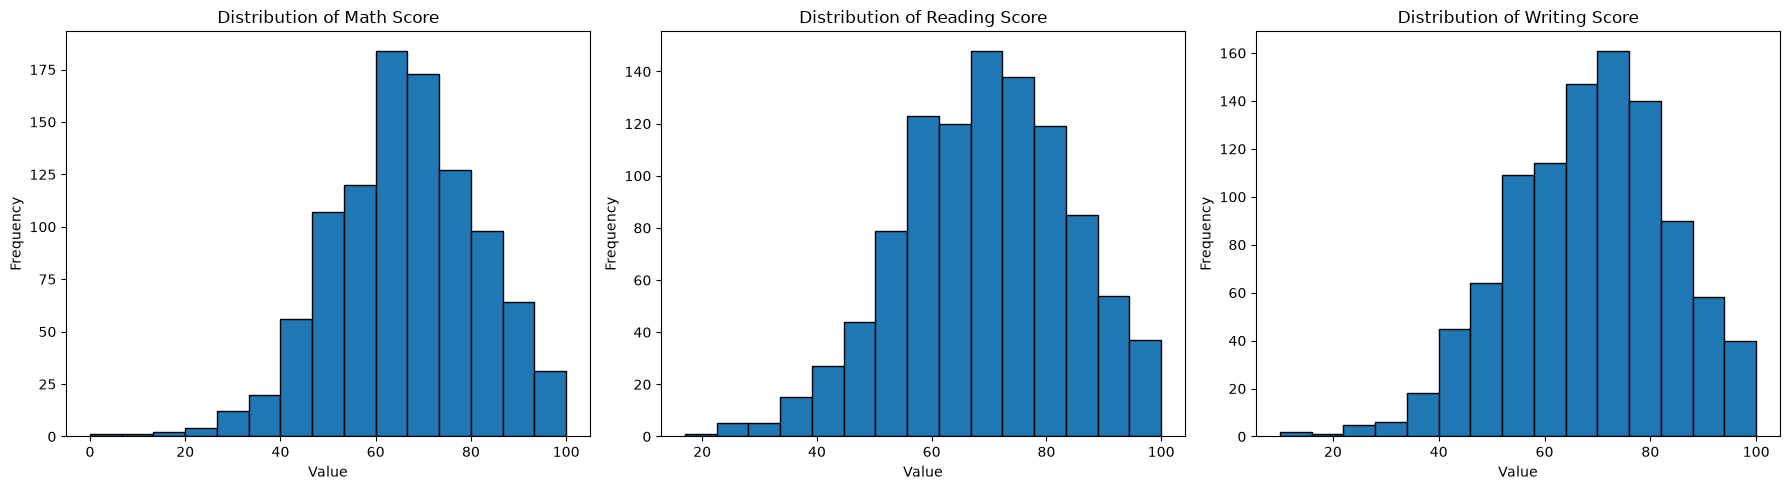

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=15, edgecolor='black')
    ax.set_title(f'Distribution of {col.title()}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Histogram Interpretations

- **Math score:** Approximately symmetric but with a slight **negative/left skew**. Most observations are concentrated roughly from the 50s through the 80s. A few very low scores create a longer lower tail. Since the distribution is slightly left-skewed, the mean is expected to be slightly lower than the median; here they are nearly equal.
- **Reading score:** Approximately symmetric with a slight **negative/left skew**. Most scores are concentrated around the 60–80 range. A few low scores extend the lower tail. The mean is slightly below the median, matching this shape.
- **Writing score:** Approximately symmetric with a slight **negative/left skew**. Most scores are around the upper 50s through the 80s, while a few low scores extend the lower tail. The mean is slightly lower than the median, which agrees with the skew direction.

None of the three histograms appears strongly uniform or clearly multimodal. The main unusual observations are the very low scores, which are investigated with the IQR rule below.

## 5. Skewness and Kurtosis

In [10]:
shape_stats = pd.DataFrame({
    'Skewness': df[num_cols].apply(lambda s: skew(s, bias=False)),
    'Kurtosis (excess)': df[num_cols].apply(lambda s: kurtosis(s, fisher=True, bias=False))
})
shape_stats.index.name = 'Variable'
display(shape_stats.round(3))

,Skewness,Kurtosis (excess)
Variable,,
math score,-0.279,0.275
reading score,-0.259,-0.068
writing score,-0.289,-0.033


### Interpretation

**Skewness**
- Math: **-0.279** → slightly left-skewed, close to symmetric.
- Reading: **-0.259** → slightly left-skewed, close to symmetric.
- Writing: **-0.289** → slightly left-skewed, close to symmetric.

All three numerical skewness values agree with the histograms: the distributions are mostly balanced but have somewhat longer lower tails.

**Kurtosis**
This notebook uses **excess kurtosis**, where a normal distribution has a value of approximately 0.
- Math: **0.275** → slightly heavier tails than a normal distribution.
- Reading: **-0.068** → very close to normal-like tail weight, slightly lighter.
- Writing: **-0.033** → very close to normal-like tail weight, slightly lighter.

The kurtosis values are all close to zero, so there is no strong evidence of extremely heavy or extremely light tails.